# Parameter Interpolability Analysis

Visualizing how well different parametric forms fit the 6 nonlinear parameters + B0/B1.

In [5]:
%load_ext autoreload
%autoreload 2
import scienceplots

import numpy as np
import matplotlib.pyplot as plt
from utils.io import load_dict
from src.visualization.pp import (
    plot_parameter_fits, plot_all_parameter_fits, plot_fit_residuals,
    fit_parametric_forms, PARAMETRIC_FORMS
)

# Load fitted parameters
params_dict=load_dict('parameters')
rsl = sorted([k for k in params_dict.keys() if isinstance(k, (float, int)) and k != 'model'])
rs_arr = np.array(rsl)

print(f"rs range: {rs_arr.min():.2f} to {rs_arr.max():.2f}")
print(f"Number of rs points: {len(rsl)}")
print(f"\nAvailable forms: {list(PARAMETRIC_FORMS.keys())}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
rs range: 0.20 to 10.00
Number of rs points: 51

Available forms: ['denom', 'superpose', 'a+b*rs^c', 'poly2', 'poly3', 'Pade[1/1]', 'Pade[2/2]', 'a+b/(rs+c)', 'saturating', 'a+b*rs^c+d*rs^e', 'sPade[1/2]', 'sPade[1/2]sqrt', 'PZ[1/1]√', 'PZ[2/1]√', 'PZ[2/2]√', 'sPZ', 'sat+bump', 'PZ[2/3]√', 'PZ[2/3]', 'mPZ[2/3]√', 'mPZ[2/3]', 'two Pade[1/1]', 'two Pade[1/1]√', 'two denom', 'PZ[3/4]', 'PZ[3/4]√', 'mPZ[3/4]']


## Overview: All 8 Parameters with Top 4 Forms

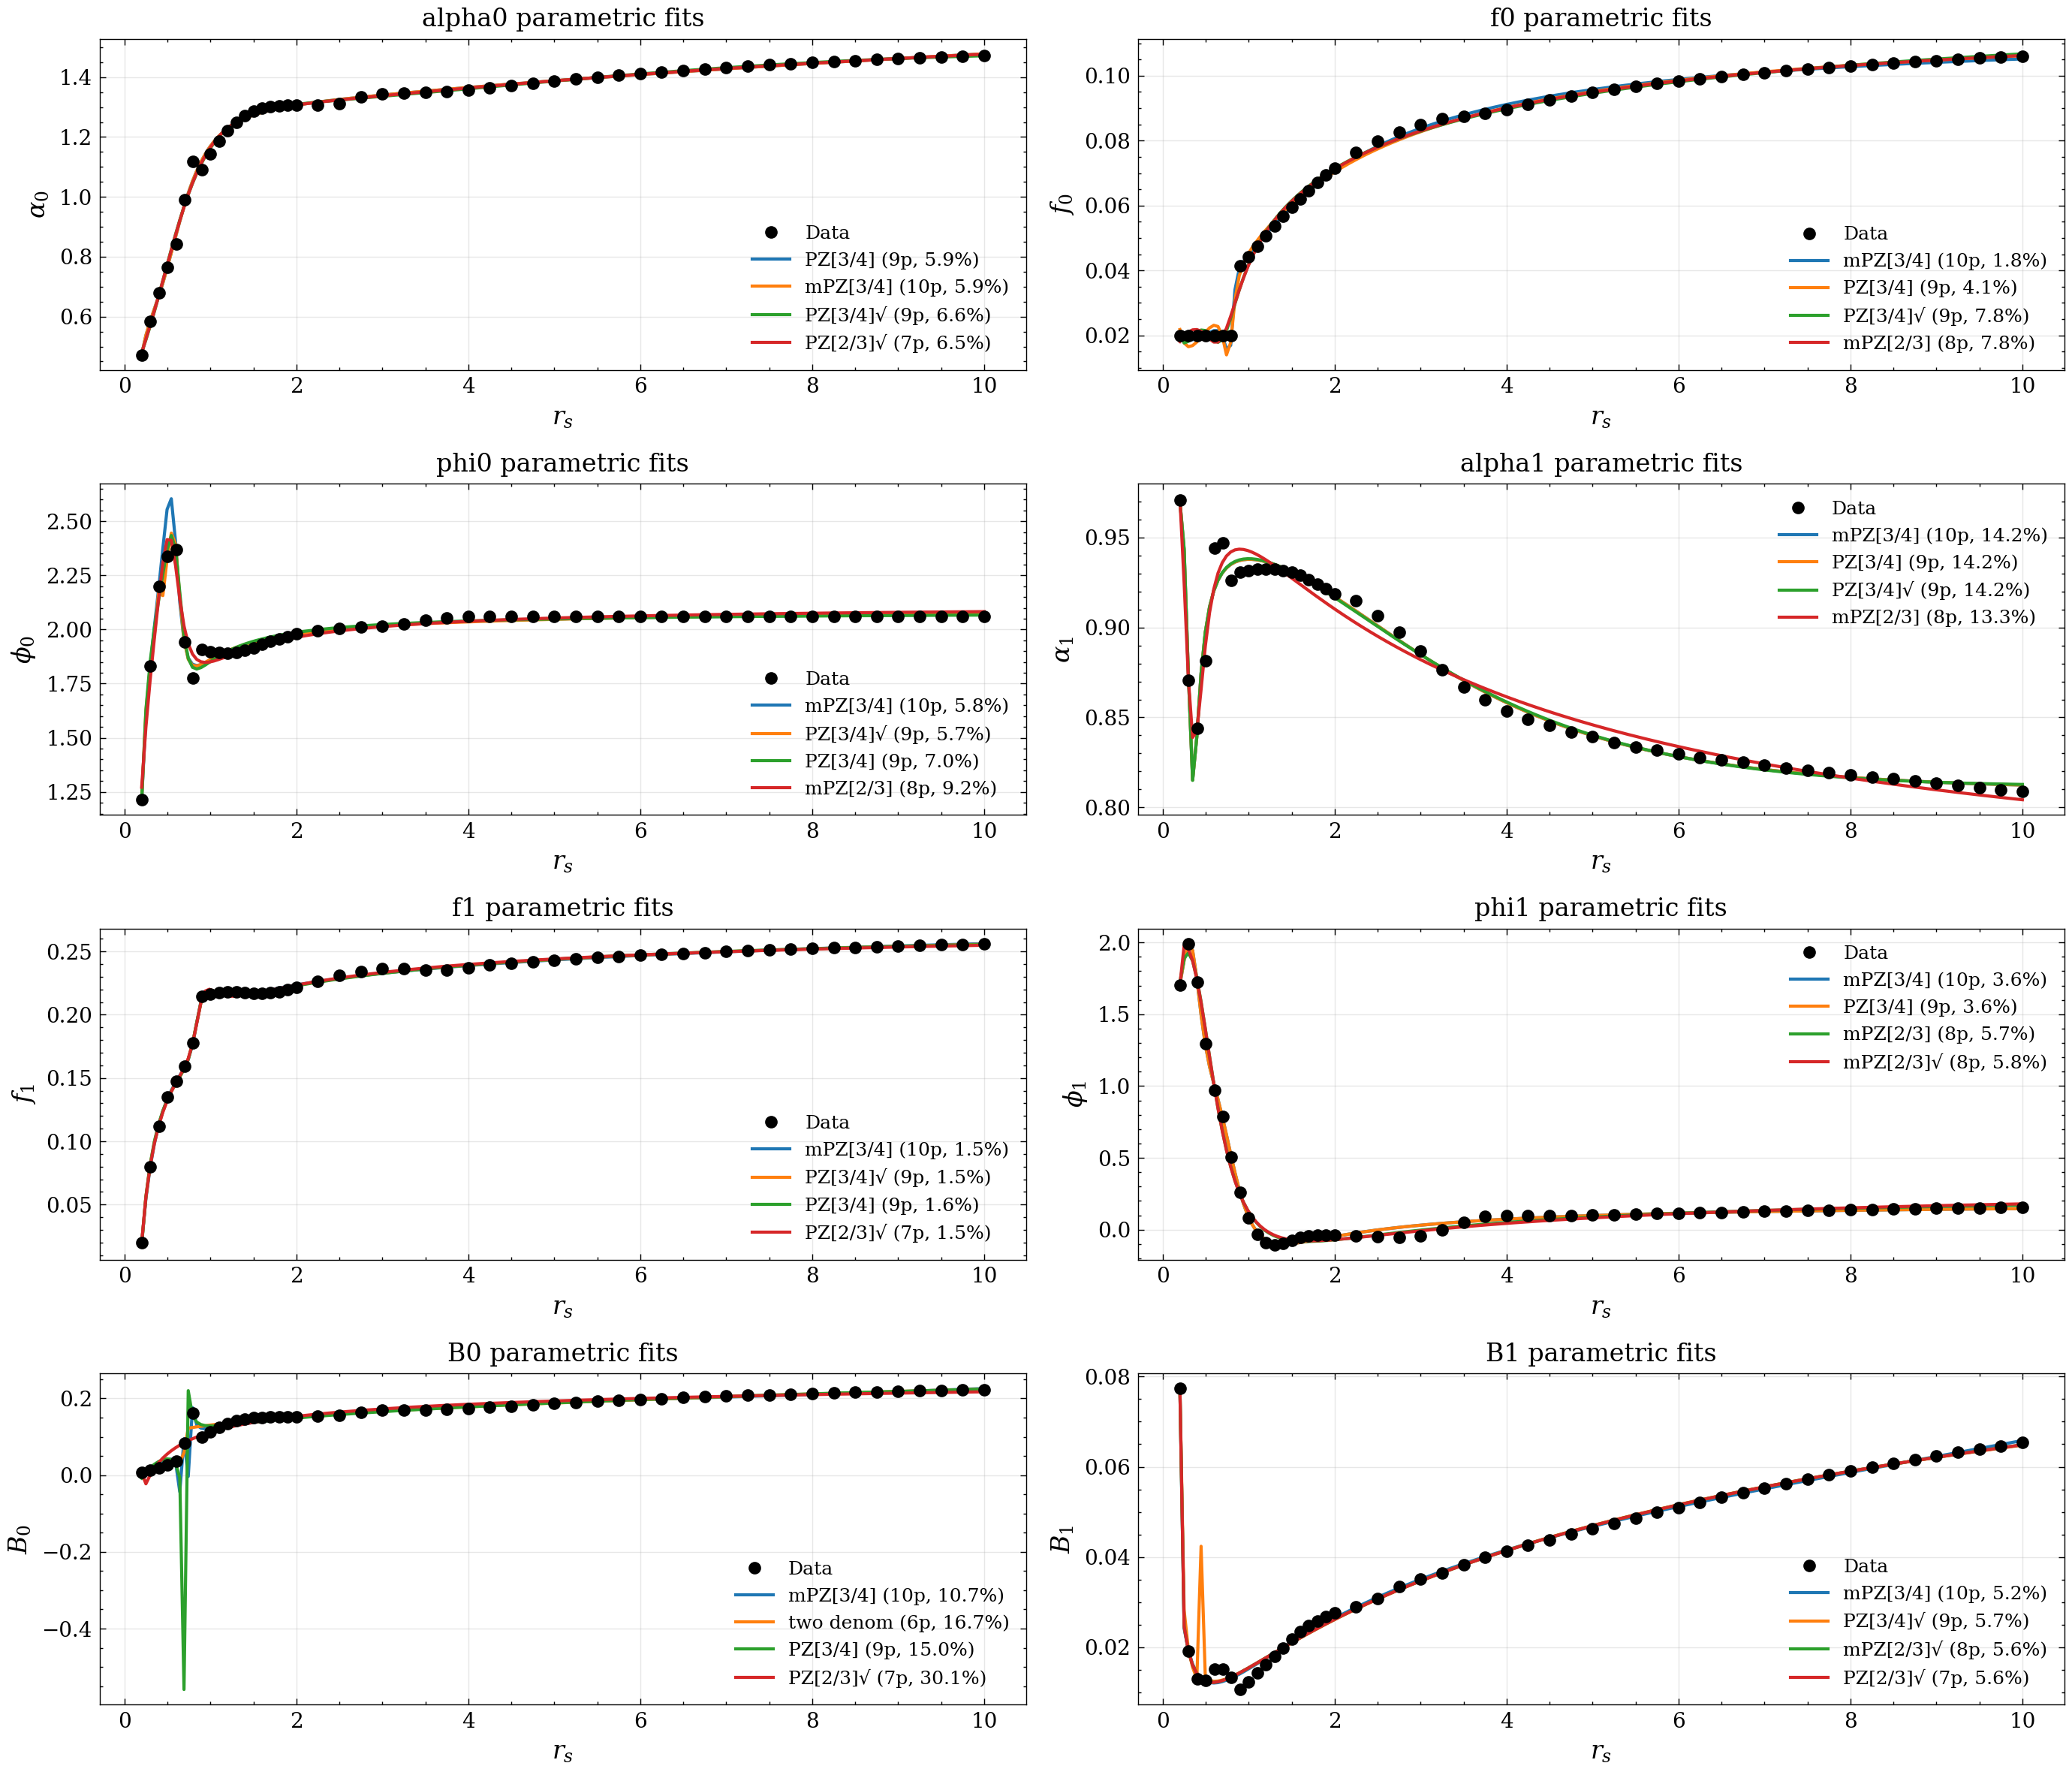

In [53]:
fig = plot_all_parameter_fits(params_dict, figsize=(14, 12))
plt.show()

## Individual Parameter Analysis

### α₀ (alpha0)

PZ[2/3]              (6p): MaxErr=  1.94%, RMSE=4.4767e-03
PZ[2/3]√             (6p): MaxErr=  2.77%, RMSE=6.1241e-03
PZ[2/2]√             (5p): MaxErr=  4.22%, RMSE=1.9380e-02
sPade[1/2]sqrt       (5p): MaxErr=  4.22%, RMSE=1.9380e-02
Pade[2/2]            (5p): MaxErr=  4.63%, RMSE=1.9802e-02
sPade[1/2]           (5p): MaxErr=  4.63%, RMSE=1.9802e-02
sPZ                  (4p): MaxErr=  4.86%, RMSE=2.0274e-02
denom                (3p): MaxErr=  5.25%, RMSE=2.2898e-02
a+b/(rs+c)           (3p): MaxErr=  5.26%, RMSE=2.4323e-02
Pade[1/1]            (3p): MaxErr=  5.26%, RMSE=2.4323e-02
a+b*rs^c+d*rs^e      (5p): MaxErr=  6.06%, RMSE=2.8416e-02
PZ[2/1]√             (4p): MaxErr=  6.18%, RMSE=2.8069e-02
PZ[1/1]√             (3p): MaxErr=  7.67%, RMSE=3.1410e-02
saturating           (3p): MaxErr=  8.21%, RMSE=3.1831e-02
sat+bump             (4p): MaxErr=  8.21%, RMSE=3.1831e-02
superpose            (4p): MaxErr= 13.39%, RMSE=4.9600e-02
a+b*rs^c             (3p): MaxErr= 21.83%, RMSE=7.2657e-

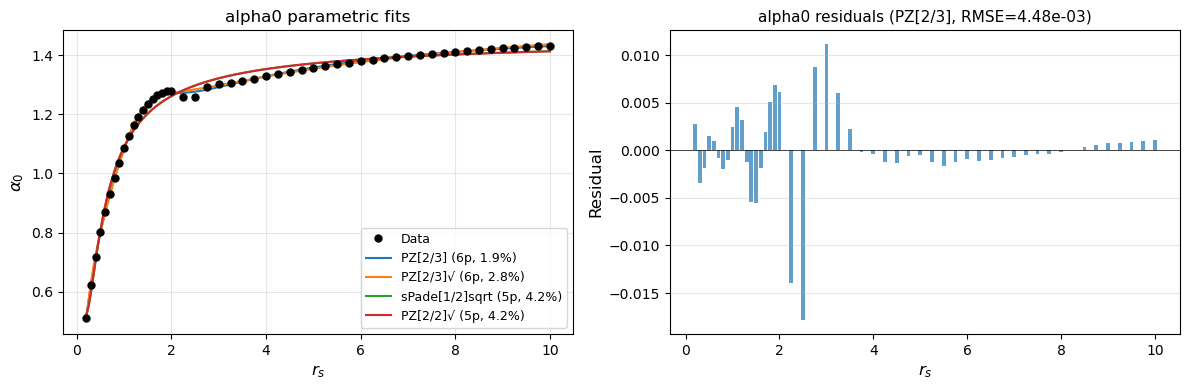

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_alpha0 = plot_parameter_fits(params_dict, param_idx=0, ax=axes[0])

# Show all form errors
sorted_results = sorted(results_alpha0.items(), key=lambda x: x[1][5])  # by maxpct
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

# Residuals for best form
best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=0, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

### f₀ (f0)

PZ[2/3]              (6p): MaxErr=  0.98%, RMSE=3.1509e-04
PZ[2/3]√             (6p): MaxErr=  1.10%, RMSE=3.2327e-04
Pade[2/2]            (5p): MaxErr=  1.56%, RMSE=5.4451e-04
sPade[1/2]           (5p): MaxErr=  1.56%, RMSE=5.4451e-04
sPZ                  (4p): MaxErr=  1.67%, RMSE=5.9871e-04
PZ[2/2]√             (5p): MaxErr=  1.80%, RMSE=5.5257e-04
saturating           (3p): MaxErr=  3.10%, RMSE=1.4287e-03
sat+bump             (4p): MaxErr=  3.10%, RMSE=1.4287e-03
poly3                (4p): MaxErr=  4.89%, RMSE=2.1243e-03
superpose            (4p): MaxErr=  5.06%, RMSE=2.0070e-03
a+b/(rs+c)           (3p): MaxErr=  5.66%, RMSE=1.4320e-03
Pade[1/1]            (3p): MaxErr=  5.66%, RMSE=1.4320e-03
a+b*rs^c+d*rs^e      (5p): MaxErr=  6.24%, RMSE=1.7386e-03
PZ[2/1]√             (4p): MaxErr=  6.97%, RMSE=1.7300e-03
sPade[1/2]sqrt       (5p): MaxErr=  6.97%, RMSE=1.7304e-03
denom                (3p): MaxErr=  7.62%, RMSE=1.4203e-03
a+b*rs^c             (3p): MaxErr= 10.12%, RMSE=3.1425e-

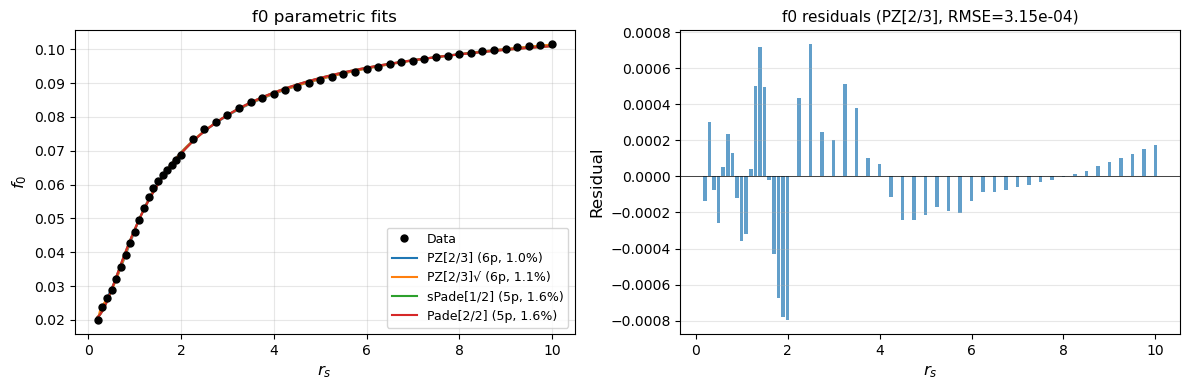

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_f0 = plot_parameter_fits(params_dict, param_idx=1, ax=axes[0])

sorted_results = sorted(results_f0.items(), key=lambda x: x[1][5])
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=1, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

### φ₀ (phi0) - The Problematic One

PZ[2/3]              (6p): MaxErr=  5.42%, RMSE=3.4441e-03
PZ[2/3]√             (6p): MaxErr=  5.86%, RMSE=4.3418e-03
sPade[1/2]           (5p): MaxErr= 27.00%, RMSE=9.6963e-03
Pade[2/2]            (5p): MaxErr= 27.00%, RMSE=9.6963e-03
sPade[1/2]sqrt       (5p): MaxErr= 29.56%, RMSE=1.0493e-02
PZ[2/2]√             (5p): MaxErr= 29.56%, RMSE=1.0493e-02
sat+bump             (4p): MaxErr= 33.18%, RMSE=2.1892e-02
superpose            (4p): MaxErr= 40.33%, RMSE=3.0956e-02
poly3                (4p): MaxErr= 41.06%, RMSE=2.9597e-02
a+b*rs^c+d*rs^e      (5p): MaxErr= 41.62%, RMSE=3.1778e-02
PZ[2/1]√             (4p): MaxErr= 42.62%, RMSE=3.2614e-02
poly2                (3p): MaxErr= 43.31%, RMSE=3.0514e-02
saturating           (3p): MaxErr= 44.55%, RMSE=3.1795e-02
Pade[1/1]            (3p): MaxErr= 44.91%, RMSE=3.2336e-02
a+b/(rs+c)           (3p): MaxErr= 44.91%, RMSE=3.2336e-02
sPZ                  (4p): MaxErr= 45.47%, RMSE=1.5213e-02
a+b*rs^c             (3p): MaxErr= 46.20%, RMSE=3.3657e-

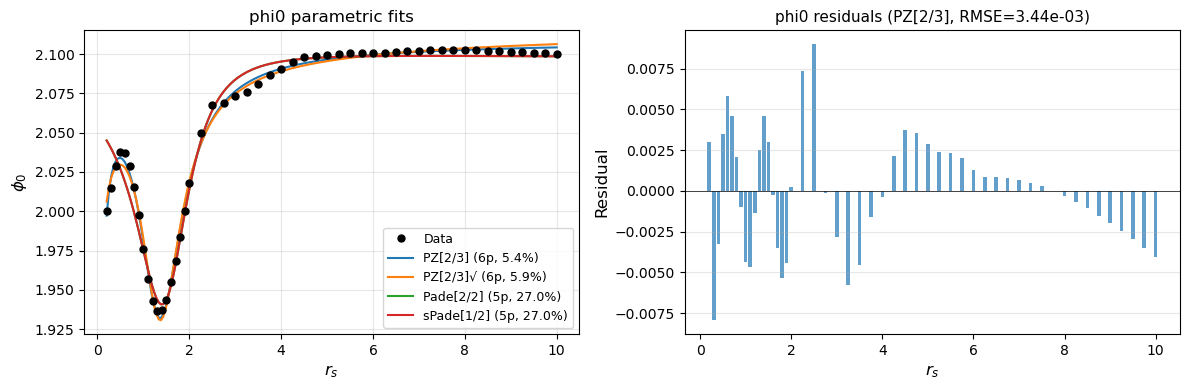

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_phi0 = plot_parameter_fits(params_dict, param_idx=2, ax=axes[0])

sorted_results = sorted(results_phi0.items(), key=lambda x: x[1][5])
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=2, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

### α₁ (alpha1)

PZ[2/3]              (6p): MaxErr=  5.20%, RMSE=1.8413e-03
PZ[2/3]√             (6p): MaxErr=  5.21%, RMSE=1.8477e-03
PZ[2/2]√             (5p): MaxErr=  5.34%, RMSE=1.9493e-03
sPade[1/2]sqrt       (5p): MaxErr=  5.34%, RMSE=1.9493e-03
Pade[2/2]            (5p): MaxErr=  5.36%, RMSE=1.9902e-03
sPade[1/2]           (5p): MaxErr=  5.36%, RMSE=1.9902e-03
sat+bump             (4p): MaxErr= 13.07%, RMSE=4.7193e-03
PZ[2/1]√             (4p): MaxErr= 21.57%, RMSE=1.1092e-02
sPZ                  (4p): MaxErr= 22.72%, RMSE=5.4906e-03
a+b*rs^c+d*rs^e      (5p): MaxErr= 24.85%, RMSE=1.0958e-02
poly3                (4p): MaxErr= 27.09%, RMSE=1.3694e-02
superpose            (4p): MaxErr= 38.93%, RMSE=1.2550e-02
saturating           (3p): MaxErr= 52.60%, RMSE=2.8221e-02
poly2                (3p): MaxErr= 58.69%, RMSE=2.0721e-02
denom                (3p): MaxErr= 65.65%, RMSE=2.0883e-02
Pade[1/1]            (3p): MaxErr= 68.07%, RMSE=2.1646e-02
PZ[1/1]√             (3p): MaxErr= 68.40%, RMSE=2.2052e-

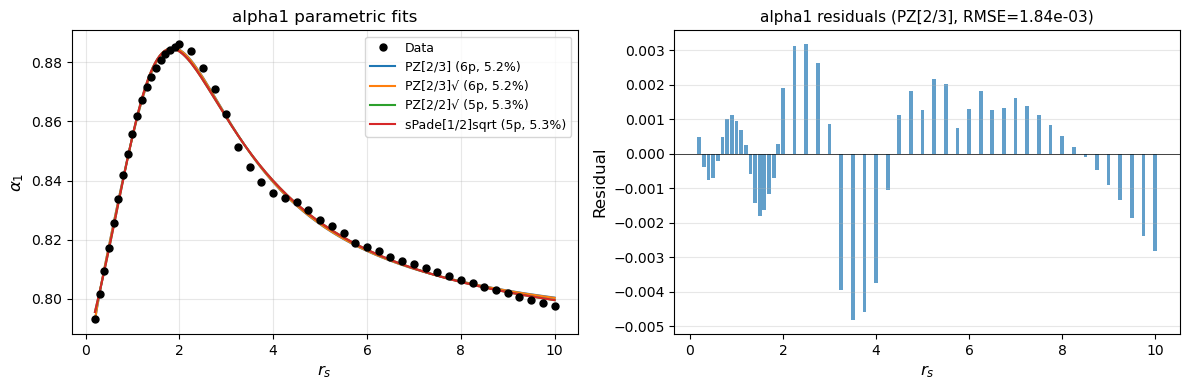

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_alpha1 = plot_parameter_fits(params_dict, param_idx=3, ax=axes[0])

sorted_results = sorted(results_alpha1.items(), key=lambda x: x[1][5])
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=3, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

### f₁ (f1)

Pade[2/2]            (5p): MaxErr=  8.00%, RMSE=3.8645e-03
PZ[2/3]              (6p): MaxErr=  8.12%, RMSE=3.8787e-03
sPade[1/2]           (5p): MaxErr=  8.17%, RMSE=3.8961e-03
sPade[1/2]sqrt       (5p): MaxErr=  8.36%, RMSE=4.1719e-03
a+b/(rs+c)           (3p): MaxErr=  8.62%, RMSE=4.8412e-03
Pade[1/1]            (3p): MaxErr=  8.62%, RMSE=4.8412e-03
PZ[2/2]√             (5p): MaxErr=  8.79%, RMSE=4.1691e-03
PZ[1/1]√             (3p): MaxErr=  8.96%, RMSE=4.3955e-03
sPZ                  (4p): MaxErr=  8.96%, RMSE=4.3955e-03
PZ[2/1]√             (4p): MaxErr=  9.10%, RMSE=4.2982e-03
denom                (3p): MaxErr=  9.16%, RMSE=4.5750e-03
a+b*rs^c+d*rs^e      (5p): MaxErr= 10.02%, RMSE=4.7563e-03
saturating           (3p): MaxErr= 10.65%, RMSE=7.4767e-03
sat+bump             (4p): MaxErr= 10.65%, RMSE=7.4767e-03
PZ[2/3]√             (6p): MaxErr= 11.40%, RMSE=2.9390e-03
superpose            (4p): MaxErr= 12.34%, RMSE=6.2190e-03
a+b*rs^c             (3p): MaxErr= 19.70%, RMSE=7.8063e-

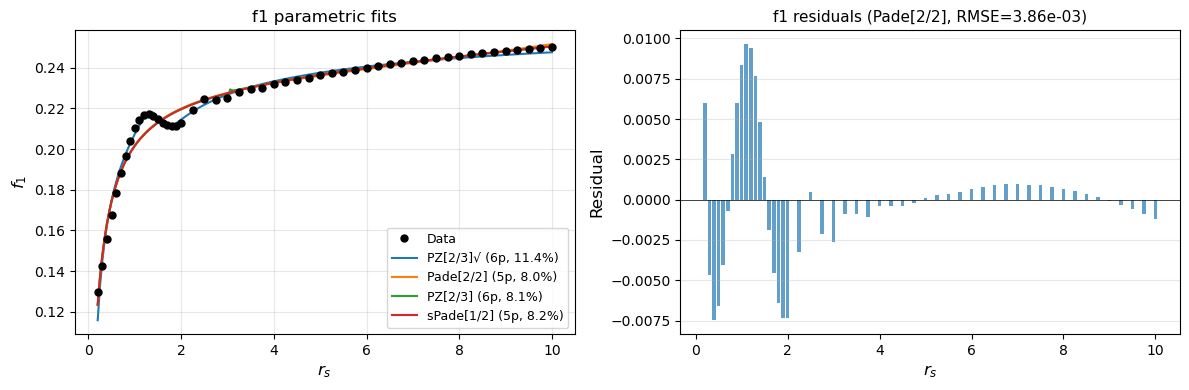

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_f1 = plot_parameter_fits(params_dict, param_idx=4, ax=axes[0])

sorted_results = sorted(results_f1.items(), key=lambda x: x[1][5])
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=4, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

### φ₁ (phi1)

PZ[2/3]√             (6p): MaxErr=  2.29%, RMSE=1.8785e-02
sPade[1/2]           (5p): MaxErr=  3.97%, RMSE=3.5212e-02
Pade[2/2]            (5p): MaxErr=  3.97%, RMSE=3.5212e-02
PZ[2/2]√             (5p): MaxErr=  4.78%, RMSE=4.4307e-02
sPade[1/2]sqrt       (5p): MaxErr=  4.78%, RMSE=4.4307e-02
sat+bump             (4p): MaxErr=  8.67%, RMSE=6.2578e-02
denom                (3p): MaxErr= 12.93%, RMSE=1.9054e-01
sPZ                  (4p): MaxErr= 13.84%, RMSE=1.3179e-01
PZ[2/1]√             (4p): MaxErr= 14.82%, RMSE=1.3835e-01
Pade[1/1]            (3p): MaxErr= 19.98%, RMSE=1.9312e-01
superpose            (4p): MaxErr= 20.74%, RMSE=1.6214e-01
a+b/(rs+c)           (3p): MaxErr= 20.84%, RMSE=1.9268e-01
PZ[1/1]√             (3p): MaxErr= 24.02%, RMSE=2.5981e-01
poly3                (4p): MaxErr= 37.13%, RMSE=2.7290e-01
a+b*rs^c             (3p): MaxErr= 47.78%, RMSE=3.4364e-01
poly2                (3p): MaxErr= 58.54%, RMSE=3.6409e-01
saturating           (3p): MaxErr= 74.23%, RMSE=4.2304e-

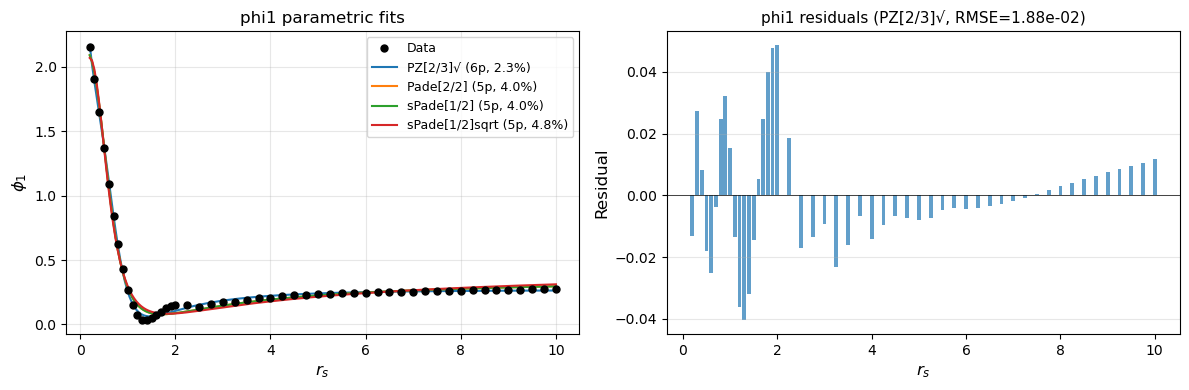

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_phi1 = plot_parameter_fits(params_dict, param_idx=5, ax=axes[0])

sorted_results = sorted(results_phi1.items(), key=lambda x: x[1][5])
for name, (_, ncoeff, _, rmse, _, maxpct) in sorted_results:
    print(f"{name:20s} ({ncoeff}p): MaxErr={maxpct:6.2f}%, RMSE={rmse:.4e}")

best_form = sorted_results[0][0]
plot_fit_residuals(params_dict, param_idx=5, form_name=best_form, ax=axes[1])
plt.tight_layout()
plt.show()

## Summary Table

In [37]:
import pandas as pd

summary_data = []
param_names = ["alpha0", "f0", "phi0", "alpha1", "f1", "phi1", "B0", "B1"]

for i, pname in enumerate(param_names):
    results = plot_parameter_fits(params_dict, param_idx=i)
    sorted_results = sorted(results.items(), key=lambda x: x[1][5])
    best_name, best_data = sorted_results[0]
    
    row = {"Parameter": pname, "Best Form": best_name, "MaxErr%": f"{best_data[5]:.2f}"}
    
    # Add your forms' performance
    for uf in ["denom", "superpose"]:
        if uf in results:
            row[f"{uf}_err%"] = f"{results[uf][5]:.2f}"
        else:
            row[f"{uf}_err%"] = "N/A"
    
    summary_data.append(row)

df = pd.DataFrame(summary_data)
plt.close('all')
df

# Create form_map from best forms
form_map_best = {param_names[i]: summary_data[i]["Best Form"] 
                 for i in range(len(param_names))}

print("\nBest parametric forms for all parameters:")
print("form_map_best = {")
for param, form in form_map_best.items():
    print(f'    "{param}": "{form}",')
print("}")

df

/Users/muhammedxgunes/Desktop/research/chi_interpolation/src/visualization/pp.py:369: OptimizeWarning: Covariance of the parameters could not be estimated
  try:



Best parametric forms for all parameters:
form_map_best = {
    "alpha0": "PZ[2/2]√",
    "f0": "mPZ[2/3]",
    "phi0": "mPZ[2/3]√",
    "alpha1": "mPZ[2/3]√",
    "f1": "mPZ[2/3]√",
    "phi1": "mPZ[2/3]",
    "B0": "mPZ[2/3]",
    "B1": "PZ[2/3]",
}


,Parameter,Best Form,MaxErr%,denom_err%,superpose_err%
0,alpha0,PZ[2/2]√,5.39,N/A,28.41
1,f0,mPZ[2/3],7.78,16.01,21.60
2,phi0,mPZ[2/3]√,4.68,N/A,64.89
3,alpha1,mPZ[2/3]√,5.28,86.28,76.76
4,f1,mPZ[2/3]√,7.39,19.30,47.99
5,phi1,mPZ[2/3],2.66,65.74,5.39
6,B0,mPZ[2/3],14.45,33.57,35.06
7,B1,PZ[2/3],4.53,17.82,17.25


## χ(r) and χ(q) Error from Interpolation

How much error in χ do we tolerate when using parametric forms instead of the fitted parameters?

In [15]:
"""we create form_map dict from
PZ[2/2]√
Pade[2/2]
sPade[1/2]
PZ[2/2]√
Pade[2/2]
sPade[1/2]
PZ[2/2]√
sPade[1/2]
"""
form_map2 = {
    "alpha0": "PZ[2/2]",
    "f0": "Pade[2/2]",
    "phi0": "sPade[1/2]",
    "alpha1": "PZ[2/2]",
    "f1": "Pade[2/2]",
    "phi1": "sPade[1/2]",
    "B0": "PZ[2/2]",
    "B1": "sPade[1/2]",
}

In [7]:
from src.visualization.pp import (
    fit_all_parameters, get_interpolated_params, 
    plot_pi_interpolated, scan_pi_interpolation_error
)

# Fit all parameters with Padé[2/2]
fits_pade = fit_all_parameters(params_dict, form_name="sPade[1/2]sqrt")

form_map = {
    "alpha0": "Pade[2/2]",
    "f0":     "Pade[2/2]",
    "phi0":   "sPade[1/2]",      # best for bumpy phi0
    "alpha1": "PZ[2/2]√",
    "f1":     "sPade[1/2]sqrt",
    "phi1":   "Pade[2/2]",
}



print("Parameter fit quality (Padé[2/2]):")
for pname in ["alpha0", "f0", "phi0", "alpha1", "f1", "phi1"]:
    info = fits_pade[pname]
    if info["popt"] is not None:
        print(f"  {pname:8s}: MaxErr = {info['maxpct']:.2f}%, RMSE = {info['rmse']:.4e}")
    else:
        print(f"  {pname:8s}: FAILED - {info['error']}")

Parameter fit quality (Padé[2/2]):
  alpha0  : MaxErr = 6.93%, RMSE = 2.5621e-02
  f0      : MaxErr = 12.94%, RMSE = 2.3787e-03
  phi0    : MaxErr = 32.87%, RMSE = 9.9773e-02
  alpha1  : MaxErr = 44.96%, RMSE = 1.6106e-02
  f1      : MaxErr = 9.49%, RMSE = 6.2583e-03
  phi1    : MaxErr = 6.46%, RMSE = 4.3291e-02


In [35]:
params_dict.keys()

dict_keys(['model', 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75, 10.0, 4.75, 4.5, 4.25, 4.0, 3.75, 3.5, 3.25, 3.0, 2.75, 2.5, 2.25, 2.0, 1.9000000000000006, 1.8000000000000005, 1.7000000000000006, 1.6000000000000005, 1.5000000000000004, 1.4000000000000004, 1.3000000000000003, 1.2000000000000004, 1.1000000000000003, 1.0000000000000002, 0.9000000000000002, 0.8000000000000003, 0.7000000000000002, 0.6000000000000001, 0.5000000000000001, 0.4000000000000001, 0.30000000000000004, 0.2])

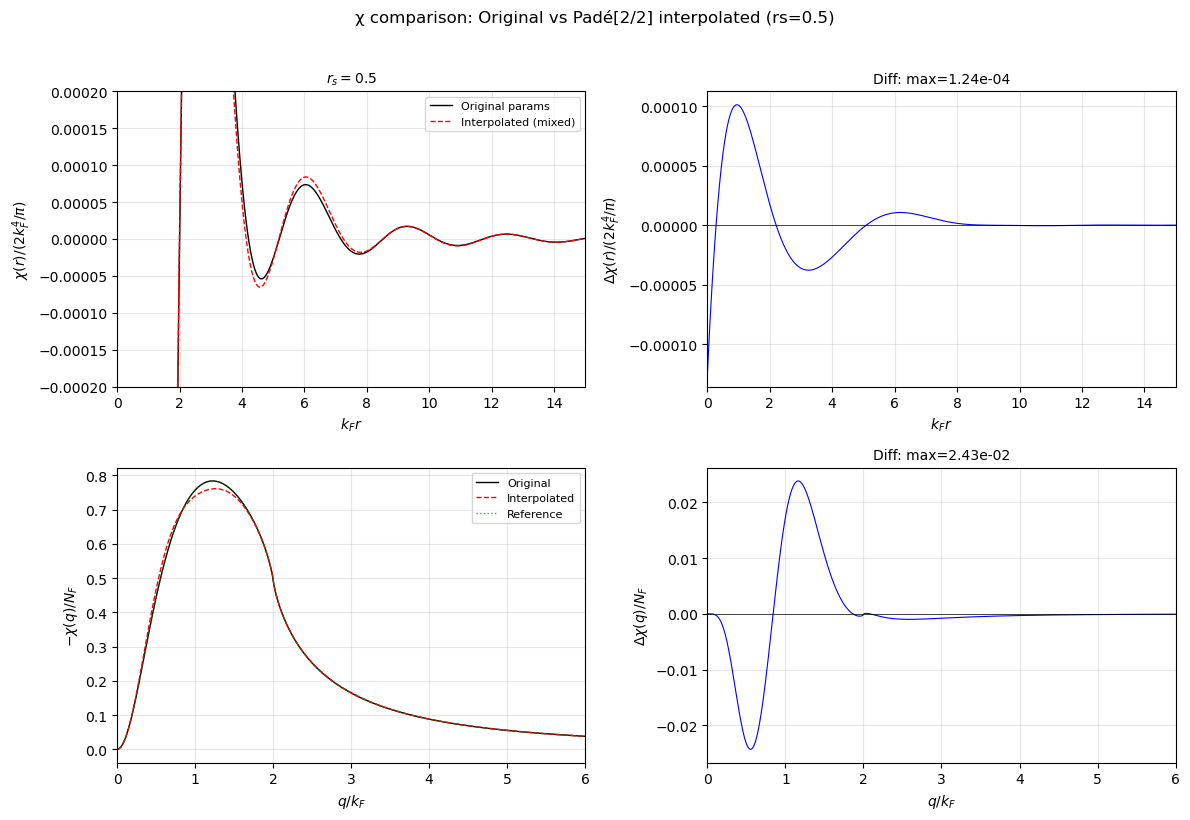


Max |Δχ(r)|: 1.24e-04
Max |Δχ(q)|: 2.43e-02


In [ ]:
# Compare χ at a specific rs
#r = np.linspace(0.01, 50, 5000)
#q = np.linspace(0.01, 10, 1000)

from input import r, q  # Assuming these are defined in input.py

rs_test = 0.5 # pick an rs to visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


form_map_best = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/2]√",
    "phi0": "PZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "PZ[2/2]√",
    "phi1": "PZ[2/3]√",
    "B0": "PZ[2/3]",
    "B1": "PZ[2/3]",
}

form_map_best2 = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/3]",
    "phi0": "mPZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "mPZ[2/3]√",
    "phi1": "mPZ[2/3]",
    "B0": "mPZ[2/3]",
    "B1": "PZ[2/3]",
}

fits = fit_all_parameters(params_dict, form_name=form_map_best)

errors = plot_chi_interpolated(r, q, params_dict, rs_test, fits, ax=axes)
plt.suptitle(f"χ comparison: Original vs Padé[2/2] interpolated (rs={rs_test})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMax |Δχ(r)|: {errors['max_diff_r']:.2e}")
print(f"Max |Δχ(q)|: {errors['max_diff_q']:.2e}")

/var/folders/1g/_ntfdbjd2n91mzhx9zdzr2t00000gn/T/ipykernel_6481/3720926876.py:8: UserWarning: rs=25 is outside the fitted range [0.5, 10.0]. Results may be unreliable.
  plt.plot(kF*rlist, chi_mhg(rlist, rs)/kF**4 )


(-0.01, 0.004)

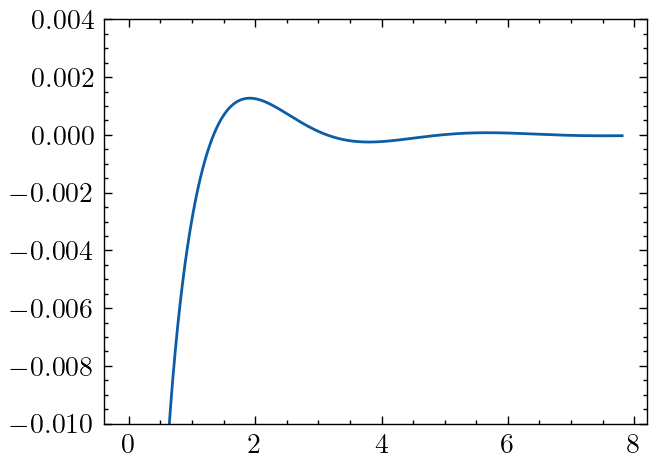

In [227]:
from chi_mhg import chi_mhg


rs=25
kF=(9*np.pi/4)**(1/3)/rs

rlist = np.linspace(0.01, 1325*kF, 5000)
plt.plot(kF*rlist, chi_mhg(rlist, rs)/kF**4 )
plt.ylim(-.01,0.004)

Scanning χ interpolation error for all rs values...


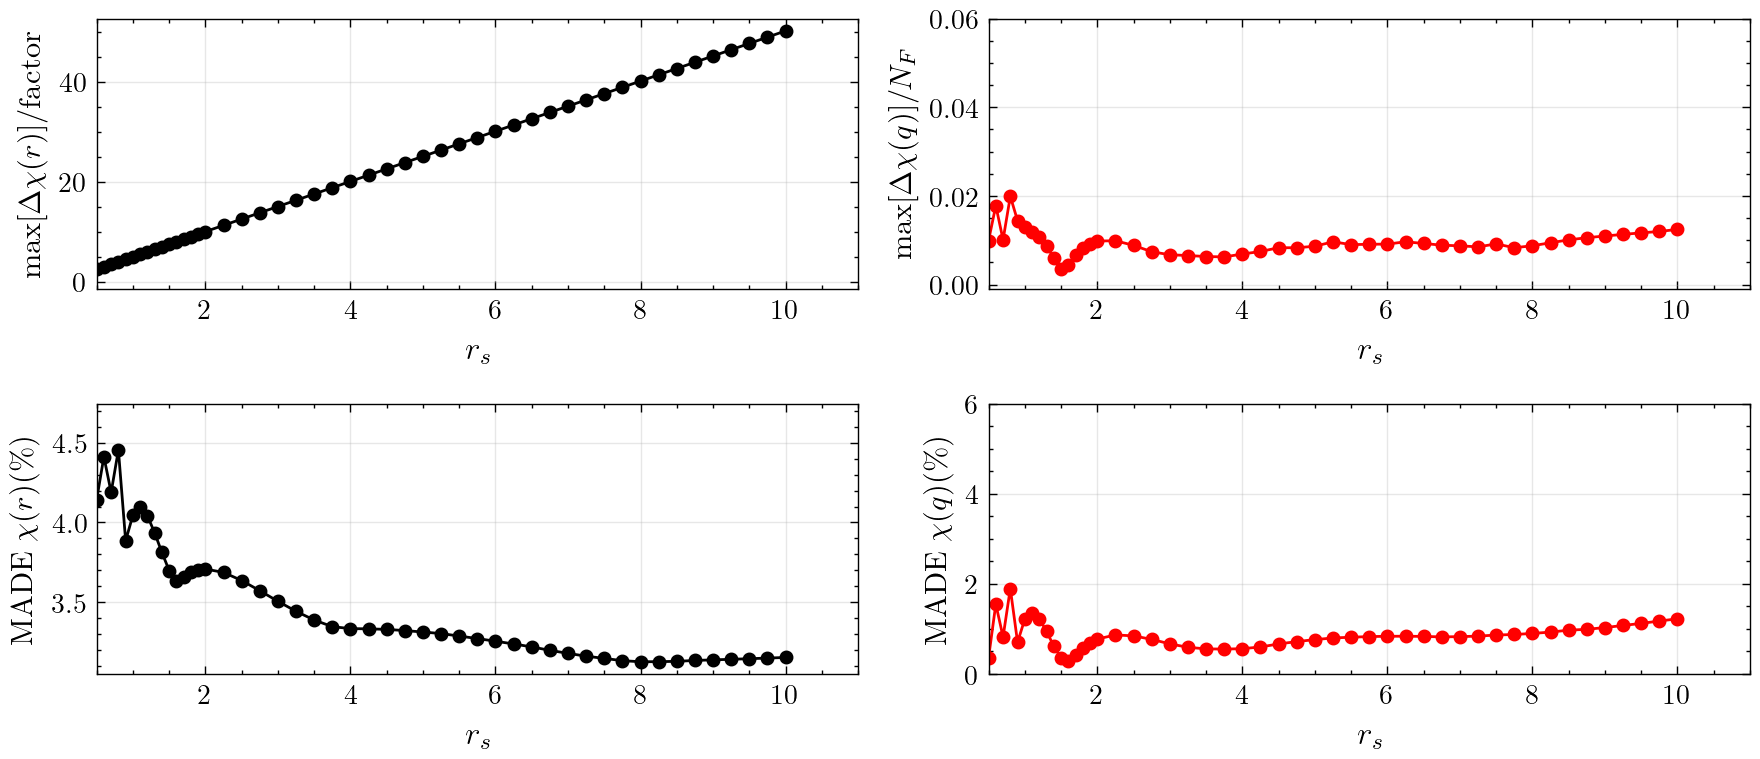


χ(r) relative error: max = 50.13%, mean = 21.32%
χ(q) relative error: max = 0.02%, mean = 0.01%


In [36]:
# Scan all rs values
from visualization.pp import scan_pi_interpolation_error
import scienceplots
plt.style.use('science')
plt.rcParams['figure.dpi'] = 200

print("Scanning χ interpolation error for all rs values...")
from input import r, q  

form_map_best = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/2]√",
    "phi0": "PZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "PZ[2/2]√",
    "phi1": "PZ[2/3]√",
}

form_map_best = {
    "alpha0": "PZ[2/2]√",
    "f0": "mPZ[2/3]",
    "phi0": "mPZ[2/3]√",
    "alpha1": "mPZ[2/3]√",
    "f1": "mPZ[2/3]√",
    "phi1": "mPZ[2/3]",
    "B0": "mPZ[2/3]",
    "B1": "PZ[2/3]",
}

results_pade, _ = scan_pi_interpolation_error(params_dict, form_name='mPZ[3/4]')

# Plot error vs rs
fig, axes = plt.subplots(2, 2, figsize=(9, 4))

rs_vals = [r["rs"] for r in results_pade]
rel_err_r = [r["rel_err_r_%"] for r in results_pade]
rel_err_q = [r["rel_err_q_%"] for r in results_pade]
MADE_r = [r["MADE_r_%"] for r in results_pade]
MADE_q = [r["MADE_q_%"] for r in results_pade]

axes[0,0].plot(rs_vals, rel_err_r, 'ko-', markersize=4)
axes[0,0].set_xlabel(r"$r_s$", fontsize=12)
axes[0,0].set_ylabel(r" $\mathrm{max}[\Delta \chi(r)] / \mathrm{factor}$", fontsize=11)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rs_vals, rel_err_q, 'ro-', markersize=4)
axes[0,1].set_xlabel(r"$r_s$", fontsize=12)
axes[0,1].set_ylabel(r"$\mathrm{max}[\Delta \chi(q)] /N_F$", fontsize=11)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(rs_vals, MADE_r, 'ko-', markersize=4)
axes[1,0].set_xlabel(r"$r_s$", fontsize=12)
axes[1,0].set_ylabel(r"MADE $\chi(r)(\%)$", fontsize=11)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(rs_vals, MADE_q, 'ro-', markersize=4)
axes[1,1].set_xlabel(r"$r_s$", fontsize=12)
axes[1,1].set_ylabel(r"MADE $\chi(q)(\%)$", fontsize=11)
axes[1,1].grid(True, alpha=0.3)


for ax in axes.flatten():
    ax.set_xlim(0.5,11)

axes[0,1].set_ylim(-0.001,0.06)
axes[1,1].set_ylim(-0.001,6)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nχ(r) relative error: max = {max(rel_err_r):.2f}%, mean = {np.mean(rel_err_r):.2f}%")
print(f"χ(q) relative error: max = {max(rel_err_q):.2f}%, mean = {np.mean(rel_err_q):.2f}%")

In [3]:
import numpy as np, time

A = np.random.rand(3000,3000)
B = np.random.rand(3000,3000)

t=time.time()
C=A@B
print(time.time()-t)

0.15611934661865234


In [ ]:
# Scan all rs values
import scienceplots
plt.style.use('science')
plt.rcParams['figure.dpi'] = 200

print("Scanning χ interpolation error for all rs values...")
from input import r, q  

form_map_best = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/2]√",
    "phi0": "PZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "PZ[2/2]√",
    "phi1": "PZ[2/3]√",
}

form_map_best = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/2]√",
    "phi0": "mPZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "PZ[2/2]√",
    "phi1": "mPZ[2/3]",
}

results_pade, _ = scan_pi_interpolation_error(params_dict, form_name='mPZ[2/3]√')

# Plot error vs rs
fig, axes = plt.subplots(2, 2, figsize=(9, 4))

rs_vals = [r["rs"] for r in results_pade]
rel_err_r = [r["rel_err_r_%"] for r in results_pade]
rel_err_q = [r["rel_err_q_%"] for r in results_pade]
MADE_r = [r["MADE_r_%"] for r in results_pade]
MADE_q = [r["MADE_q_%"] for r in results_pade]

axes[0,0].plot(rs_vals, rel_err_r, 'ko-', markersize=4)
axes[0,0].set_xlabel(r"$r_s$", fontsize=12)
axes[0,0].set_ylabel(r" $\mathrm{max}[\Delta \chi(r)] / \mathrm{factor}$", fontsize=11)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rs_vals, rel_err_q, 'ro-', markersize=4)
axes[0,1].set_xlabel(r"$r_s$", fontsize=12)
axes[0,1].set_ylabel(r"$\mathrm{max}[\Delta \chi(q)] /N_F$", fontsize=11)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(rs_vals, MADE_r, 'ko-', markersize=4)
axes[1,0].set_xlabel(r"$r_s$", fontsize=12)
axes[1,0].set_ylabel(r"MADE $\chi(r)(\%)$", fontsize=11)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(rs_vals, MADE_q, 'ro-', markersize=4)
axes[1,1].set_xlabel(r"$r_s$", fontsize=12)
axes[1,1].set_ylabel(r"MADE $\chi(q)(\%)$", fontsize=11)
axes[1,1].grid(True, alpha=0.3)


for ax in axes.flatten():
    ax.set_xlim(0.5,11)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nχ(r) relative error: max = {max(rel_err_r):.2f}%, mean = {np.mean(rel_err_r):.2f}%")
print(f"χ(q) relative error: max = {max(rel_err_q):.2f}%, mean = {np.mean(rel_err_q):.2f}%")

Scanning χ interpolation error for all rs values...


NameError: name 'scan_chi_interpolation_error' is not defined

In [186]:
np.max(rel_err_q[3:]), np.mean(MADE_q)

(0.026839680542615936, 0.8392772464132326)

Scanning χ interpolation error for all rs values...


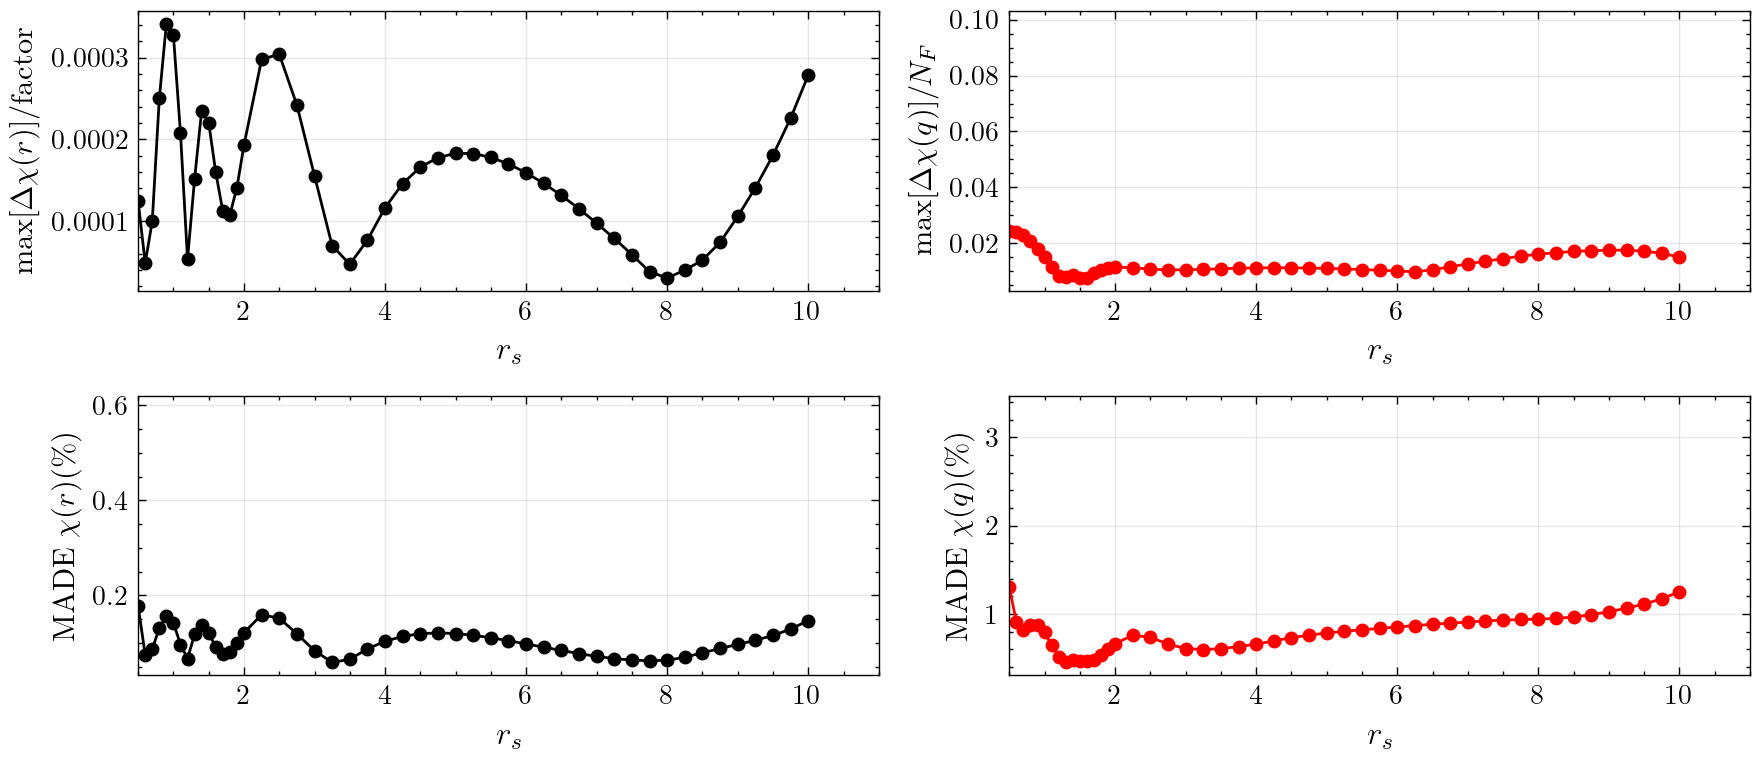


χ(r) relative error: max = 0.00%, mean = 0.00%
χ(q) relative error: max = 0.10%, mean = 0.02%


In [171]:
# Scan all rs values
import scienceplots
plt.style.use('science')
plt.rcParams['figure.dpi'] = 200

print("Scanning χ interpolation error for all rs values...")
from input import r, q  

form_map_best = {
    "alpha0": "PZ[2/3]",
    "f0": "PZ[2/2]√",
    "phi0": "PZ[2/3]",
    "alpha1": "PZ[2/3]",
    "f1": "PZ[2/2]√",
    "phi1": "PZ[2/3]√",
}


results_pade, _ = scan_chi_interpolation_error(params_dict, form_name=form_map_best)

# Plot error vs rs
fig, axes = plt.subplots(2, 2, figsize=(9, 4))

rs_vals = [r["rs"] for r in results_pade]
rel_err_r = [r["rel_err_r_%"] for r in results_pade]
rel_err_q = [r["rel_err_q_%"] for r in results_pade]
MADE_r = [r["MADE_r_%"] for r in results_pade]
MADE_q = [r["MADE_q_%"] for r in results_pade]

axes[0,0].plot(rs_vals, rel_err_r, 'ko-', markersize=4)
axes[0,0].set_xlabel(r"$r_s$", fontsize=12)
axes[0,0].set_ylabel(r" $\mathrm{max}[\Delta \chi(r)] / \mathrm{factor}$", fontsize=11)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rs_vals, rel_err_q, 'ro-', markersize=4)
axes[0,1].set_xlabel(r"$r_s$", fontsize=12)
axes[0,1].set_ylabel(r"$\mathrm{max}[\Delta \chi(q)] /N_F$", fontsize=11)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(rs_vals, MADE_r, 'ko-', markersize=4)
axes[1,0].set_xlabel(r"$r_s$", fontsize=12)
axes[1,0].set_ylabel(r"MADE $\chi(r)(\%)$", fontsize=11)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(rs_vals, MADE_q, 'ro-', markersize=4)
axes[1,1].set_xlabel(r"$r_s$", fontsize=12)
axes[1,1].set_ylabel(r"MADE $\chi(q)(\%)$", fontsize=11)
axes[1,1].grid(True, alpha=0.3)


for ax in axes.flatten():
    ax.set_xlim(0.5,11)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nχ(r) relative error: max = {max(rel_err_r):.2f}%, mean = {np.mean(rel_err_r):.2f}%")
print(f"χ(q) relative error: max = {max(rel_err_q):.2f}%, mean = {np.mean(rel_err_q):.2f}%")

### Compare Different Forms: Which Produces Smallest χ Error?

In [110]:
# Compare multiple forms
import pandas as pd
forms_to_test = [form_map_best]#PARAMETRIC_FORMS.keys()#["Pade[2/2]", "a+b*rs^c+d*rs^e", "denom", "superpose", "poly3"]

comparison = []
for form in forms_to_test:
    try:
        results, fits = scan_chi_interpolation_error(params_dict, form_name=form)
        max_err_r = max(r["rel_err_r_%"] for r in results)
        max_err_q = max(r["rel_err_q_%"] for r in results)
        mean_err_r = np.mean([r["rel_err_r_%"] for r in results])
        mean_err_q = np.mean([r["rel_err_q_%"] for r in results])
        
        # Also get worst param fit
        worst_param = max(["alpha0", "f0", "phi0", "alpha1", "f1", "phi1"], 
                          key=lambda p: fits[p]["maxpct"] if fits[p]["popt"] is not None else 999)
        worst_pct = fits[worst_param]["maxpct"]
        
        comparison.append({
            "Form": form,
            "max_χ(r)_%": f"{max_err_r:.2f}",
            "max_χ(q)_%": f"{max_err_q:.2f}",
            "mean_χ(r)_%": f"{mean_err_r:.3f}",
            "mean_χ(q)_%": f"{mean_err_q:.3f}",
            "worst_param": f"{worst_param}({worst_pct:.1f}%)"
        })
    except Exception as e:
        print(f"{form}: FAILED - {e}")

df_comp = pd.DataFrame(comparison)
df_comp

,Form,max_χ(r)_%,max_χ(q)_%,mean_χ(r)_%,mean_χ(q)_%,worst_param
0,"{'alpha0': 'PZ[2/3]', 'f0': 'PZ[2/2]√', 'phi0'...",0.00,0.10,0.000,0.016,f1(8.8%)


In [109]:
# Compare multiple forms
import pandas as pd
forms_to_test = PARAMETRIC_FORMS.keys()#["Pade[2/2]", "a+b*rs^c+d*rs^e", "denom", "superpose", "poly3"]

comparison = []
for form in forms_to_test:
    try:
        results, fits = scan_chi_interpolation_error(params_dict, form_name=form)
        max_err_r = max(r["rel_err_r_%"] for r in results)
        max_err_q = max(r["rel_err_q_%"] for r in results)
        mean_err_r = np.mean([r["rel_err_r_%"] for r in results])
        mean_err_q = np.mean([r["rel_err_q_%"] for r in results])
        
        # Also get worst param fit
        worst_param = max(["alpha0", "f0", "phi0", "alpha1", "f1", "phi1"], 
                          key=lambda p: fits[p]["maxpct"] if fits[p]["popt"] is not None else 999)
        worst_pct = fits[worst_param]["maxpct"]
        
        comparison.append({
            "Form": form,
            "max_χ(r)_%": f"{max_err_r:.2f}",
            "max_χ(q)_%": f"{max_err_q:.2f}",
            "mean_χ(r)_%": f"{mean_err_r:.3f}",
            "mean_χ(q)_%": f"{mean_err_q:.3f}",
            "worst_param": f"{worst_param}({worst_pct:.1f}%)"
        })
    except Exception as e:
        print(f"{form}: FAILED - {e}")

df_comp = pd.DataFrame(comparison)
df_comp

a+b*rs^c+d*rs^e: FAILED - No fit available for phi1
PZ[2/3]: FAILED - No fit available for phi1


,Form,max_χ(r)_%,max_χ(q)_%,mean_χ(r)_%,mean_χ(q)_%,worst_param
0,denom,0.00,0.38,0.001,0.062,alpha1(65.6%)
1,superpose,0.02,1.10,0.001,0.054,phi0(40.3%)
2,a+b*rs^c,0.00,0.46,0.002,0.056,alpha1(75.5%)
3,poly2,0.02,1.23,0.003,0.081,alpha1(58.7%)
4,poly3,0.00,0.87,0.001,0.052,phi0(41.1%)
5,Pade[1/1],0.01,0.66,0.001,0.051,alpha1(68.1%)
6,Pade[2/2],0.00,0.14,0.000,0.021,phi0(27.0%)
7,a+b/(rs+c),0.01,0.81,0.001,0.054,alpha1(72.3%)
8,saturating,0.00,0.13,0.001,0.052,phi1(74.2%)
9,sPade[1/2],0.00,0.14,0.000,0.021,phi0(27.0%)


In [108]:
# Compare multiple forms
import pandas as pd
forms_to_test = PARAMETRIC_FORMS.keys()#["Pade[2/2]", "a+b*rs^c+d*rs^e", "denom", "superpose", "poly3"]

comparison = []
for form in forms_to_test:
    try:
        results, fits = scan_chi_interpolation_error(params_dict, form_name=form)
        max_err_r = max(r["rel_err_r_%"] for r in results)
        max_err_q = max(r["rel_err_q_%"] for r in results)
        mean_err_r = np.mean([r["rel_err_r_%"] for r in results])
        mean_err_q = np.mean([r["rel_err_q_%"] for r in results])
        
        # Also get worst param fit
        worst_param = max(["alpha0", "f0", "phi0", "alpha1", "f1", "phi1"], 
                          key=lambda p: fits[p]["maxpct"] if fits[p]["popt"] is not None else 999)
        worst_pct = fits[worst_param]["maxpct"]
        
        comparison.append({
            "Form": form,
            "max_χ(r)_%": f"{max_err_r:.2f}",
            "max_χ(q)_%": f"{max_err_q:.2f}",
            "mean_χ(r)_%": f"{mean_err_r:.3f}",
            "mean_χ(q)_%": f"{mean_err_q:.3f}",
            "worst_param": f"{worst_param}({worst_pct:.1f}%)"
        })
    except Exception as e:
        print(f"{form}: FAILED - {e}")

df_comp = pd.DataFrame(comparison)
df_comp

a+b*rs^c+d*rs^e: FAILED - No fit available for phi1
PZ[2/3]: FAILED - No fit available for phi1


,Form,max_χ(r)_%,max_χ(q)_%,mean_χ(r)_%,mean_χ(q)_%,worst_param
0,denom,0.00,0.10,0.001,0.054,alpha1(65.6%)
1,superpose,0.00,0.05,0.001,0.022,phi0(40.3%)
2,a+b*rs^c,0.00,0.08,0.001,0.035,alpha1(75.5%)
3,poly2,0.00,0.07,0.002,0.034,alpha1(58.7%)
4,poly3,0.00,0.05,0.001,0.023,phi0(41.1%)
5,Pade[1/1],0.00,0.07,0.001,0.037,alpha1(68.1%)
6,Pade[2/2],0.00,0.03,0.000,0.015,phi0(27.0%)
7,a+b/(rs+c),0.00,0.07,0.001,0.037,alpha1(72.3%)
8,saturating,0.00,0.13,0.001,0.052,phi1(74.2%)
9,sPade[1/2],0.00,0.03,0.000,0.015,phi0(27.0%)


Worst-case rs for Padé[2/2]: rs = 0.30000000000000004
  χ(r) rel err: 0.00%
  χ(q) rel err: 9.34%


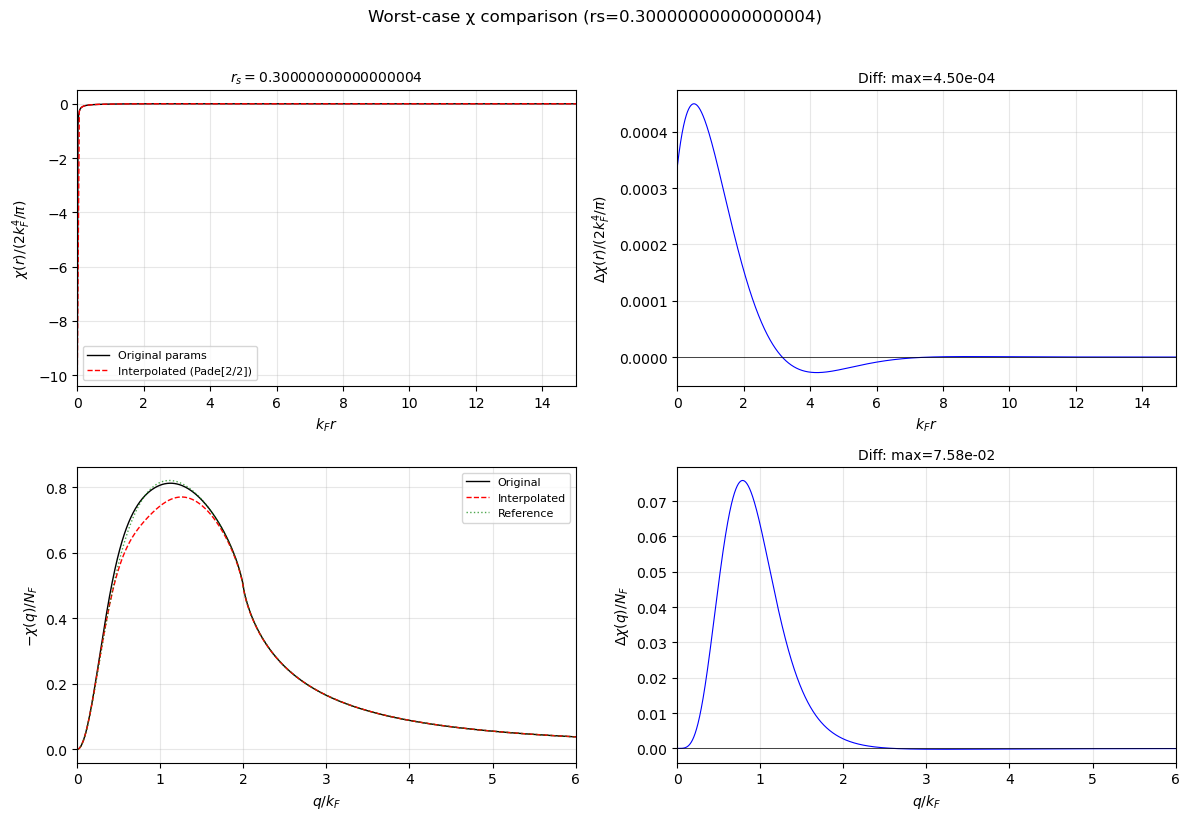

In [10]:
# Find worst-case rs and visualize
results_pade, fits_pade = scan_chi_interpolation_error(params_dict, form_name="Pade[2/2]")
worst_rs_idx = np.argmax([r["rel_err_q_%"] for r in results_pade])
worst_rs = results_pade[worst_rs_idx]["rs"]

print(f"Worst-case rs for Padé[2/2]: rs = {worst_rs}")
print(f"  χ(r) rel err: {results_pade[worst_rs_idx]['rel_err_r_%']:.2f}%")
print(f"  χ(q) rel err: {results_pade[worst_rs_idx]['rel_err_q_%']:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
errors = plot_chi_interpolated(r, q, params_dict, worst_rs, fits_pade, ax=axes)
plt.suptitle(f"Worst-case χ comparison (rs={worst_rs})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Your Forms: χ Error Comparison

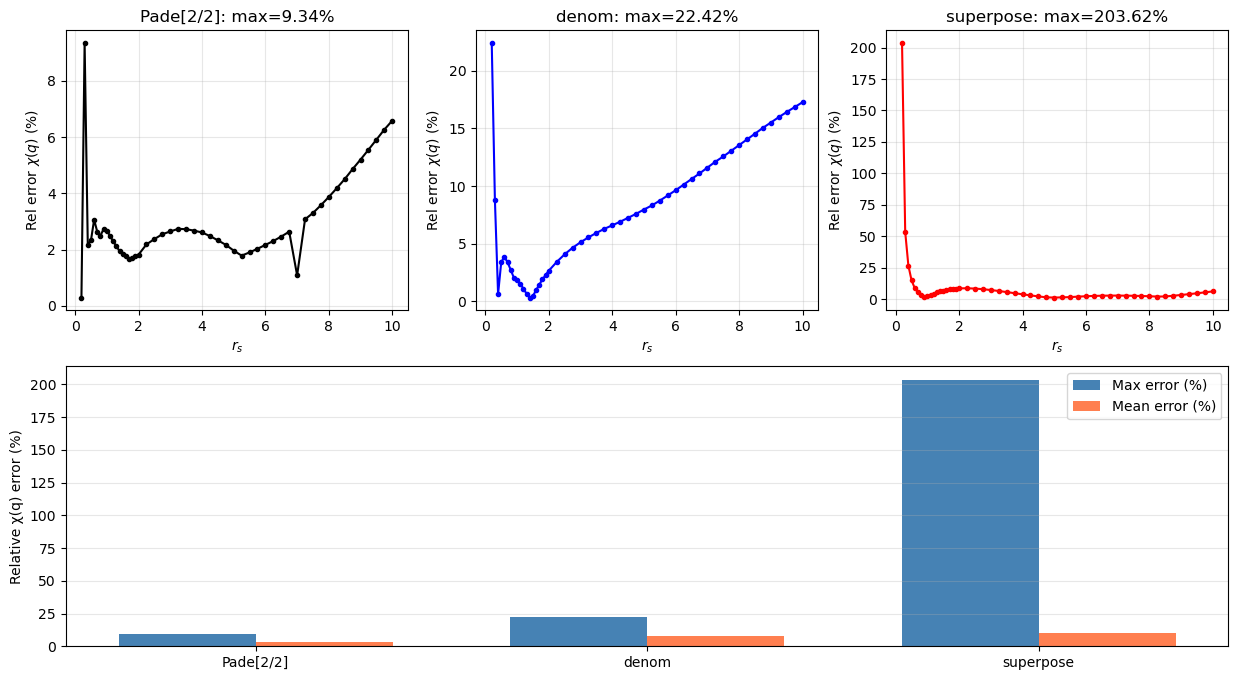

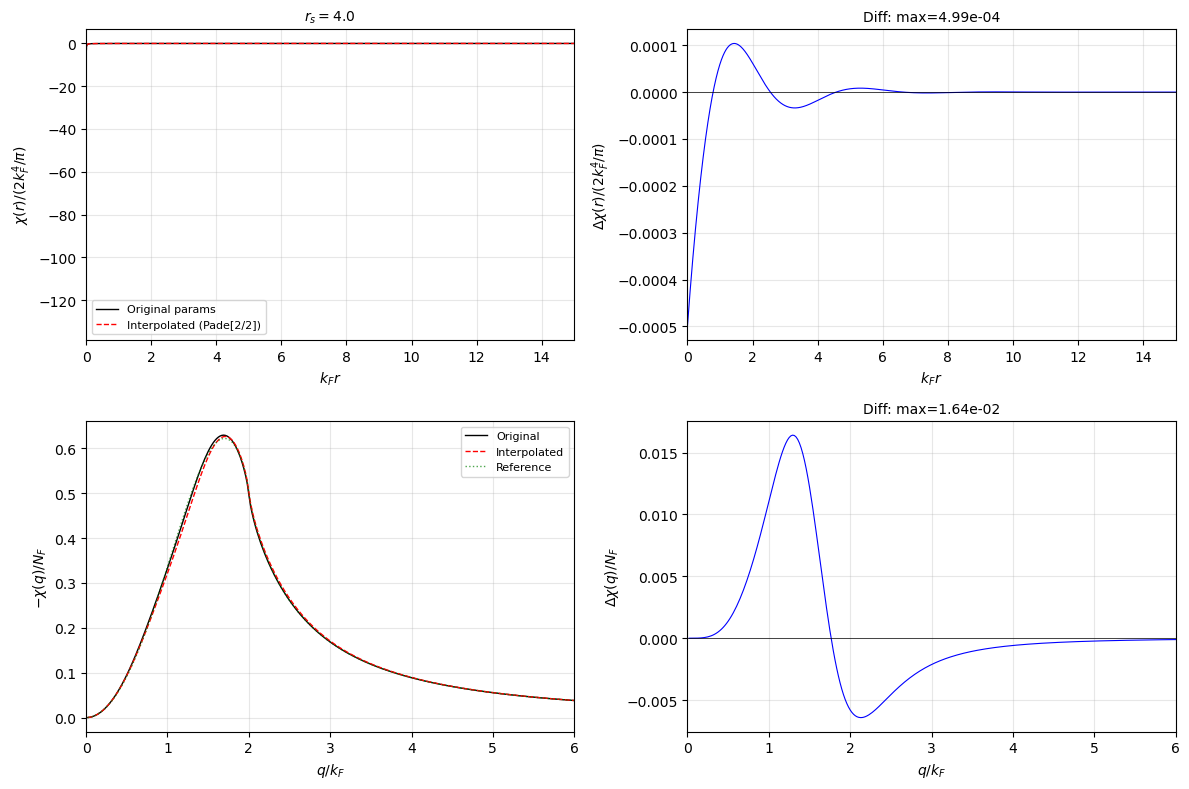

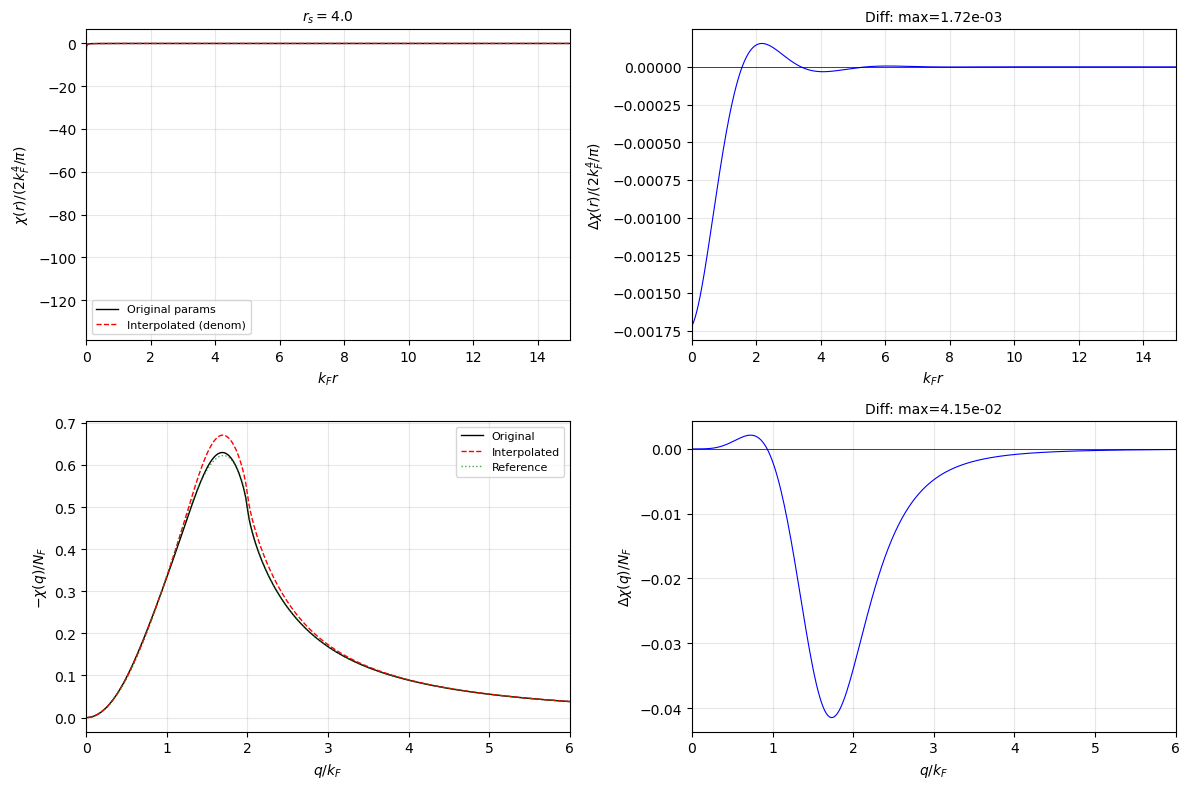

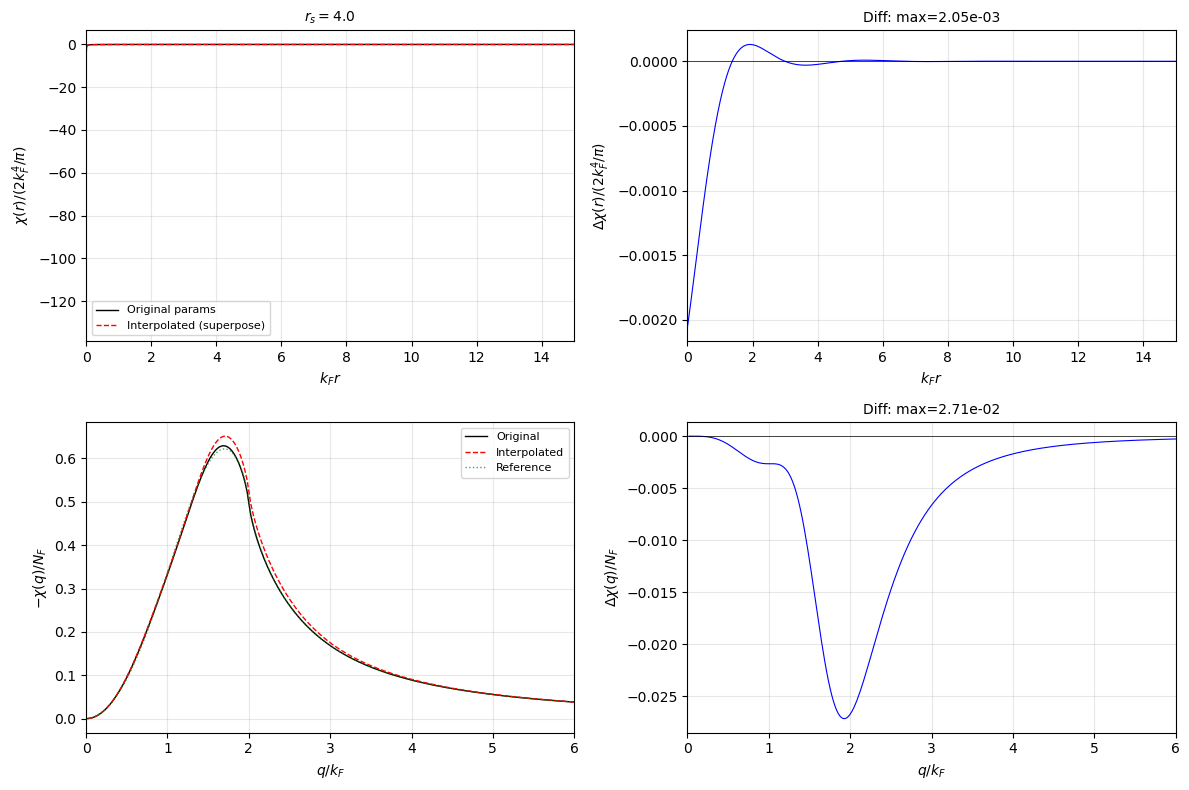

In [11]:
# Compare your forms vs Padé[2/2] at multiple rs
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

forms_user = ["Pade[2/2]", "denom", "superpose"]
colors = ['k', 'b', 'r']

for col, form_name in enumerate(forms_user):
    try:
        fits = fit_all_parameters(params_dict, form_name=form_name)
        results, _ = scan_chi_interpolation_error(params_dict, form_name=form_name)
        
        rs_vals = [r["rs"] for r in results]
        rel_err_q = [r["rel_err_q_%"] for r in results]
        
        axes[0, col].plot(rs_vals, rel_err_q, 'o-', color=colors[col], markersize=3)
        axes[0, col].set_xlabel(r"$r_s$")
        axes[0, col].set_ylabel(r"Rel error $\chi(q)$ (%)")
        axes[0, col].set_title(f"{form_name}: max={max(rel_err_q):.2f}%")
        axes[0, col].grid(True, alpha=0.3)
        
        # Show chi at rs=4.0
        plot_chi_interpolated(r, q, params_dict, 4.0, fits, ax=axes[1, col].reshape(1,1) if False else None)
    except Exception as e:
        axes[0, col].text(0.5, 0.5, f"Failed:\n{e}", ha='center', va='center', transform=axes[0, col].transAxes)

# Cleanup bottom row - show bar comparison instead
for ax in axes[1, :]:
    ax.remove()

ax_bar = fig.add_subplot(2, 1, 2)
x = np.arange(len(forms_user))
width = 0.35

max_errs = []
mean_errs = []
for form in forms_user:
    try:
        results, _ = scan_chi_interpolation_error(params_dict, form_name=form)
        max_errs.append(max(r["rel_err_q_%"] for r in results))
        mean_errs.append(np.mean([r["rel_err_q_%"] for r in results]))
    except:
        max_errs.append(0)
        mean_errs.append(0)

ax_bar.bar(x - width/2, max_errs, width, label='Max error (%)', color='steelblue')
ax_bar.bar(x + width/2, mean_errs, width, label='Mean error (%)', color='coral')
ax_bar.set_ylabel('Relative χ(q) error (%)')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(forms_user)
ax_bar.legend()
ax_bar.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Improving Interpolability

Two scripts are available to improve parameter interpolability:

1. **`test_higher_lambda.py`**: Test λ_smooth = 50, 100, 500 (currently 10)
2. **`test_pade_constrained.py`**: Force parameters to follow Padé[2/2] form

Run one of these, then reload and compare:

In [ ]:
# After running test scripts, compare the results
import os

# Check what parameter files exist
param_files = [f for f in os.listdir('.') if f.startswith('parameters') and f.endswith('.npy')]
print("Available parameter files:")
for f in sorted(param_files):
    print(f"  {f}")

# Load and compare
from scipy.optimize import curve_fit

def pade22_fit(x, a, b, c, d, e):
    return (a + b*x + c*x**2) / (1 + d*x + e*x**2)

def compute_max_interp_error(params_dict):
    """Compute max Padé[2/2] error across all 6 params."""
    rsl = sorted([k for k in params_dict.keys() if isinstance(k, (float, int)) and k != 'model'])
    rs_arr = np.array(rsl)
    data = np.array([params_dict[rs] for rs in rsl])
    
    labels = ['alpha0', 'f0', 'phi0', 'alpha1', 'f1', 'phi1']
    errors = {}
    for i, lab in enumerate(labels):
        y = data[:, i]
        rng = y.max() - y.min()
        try:
            popt, _ = curve_fit(pade22_fit, rs_arr, y, maxfev=50000)
            pred = pade22_fit(rs_arr, *popt)
            errors[lab] = np.max(np.abs(pred - y)) / (rng + 1e-30) * 100
        except:
            errors[lab] = 999.0
    return errors

# Compare available param files
comparison = []
for f in param_files:
    name = f.replace('.npy', '')
    try:
        p = np.load(f, allow_pickle=True).item()
        errors = compute_max_interp_error(p)
        comparison.append({
            'File': name,
            'alpha0': f"{errors['alpha0']:.1f}%",
            'f0': f"{errors['f0']:.1f}%",
            'phi0': f"{errors['phi0']:.1f}%", 
            'alpha1': f"{errors['alpha1']:.1f}%",
            'f1': f"{errors['f1']:.1f}%",
            'phi1': f"{errors['phi1']:.1f}%",
            'max': f"{max(errors.values()):.1f}%"
        })
    except:
        pass

if comparison:
    df_comp = pd.DataFrame(comparison)
    display(df_comp)
else:
    print("No valid parameter files found. Run test_higher_lambda.py or test_pade_constrained.py first.")